# Settings

- It defaults to B, but you simply need to change CLASS_FOLDER to M or N to establish the neighborhood relationship between the images of each class.
- To preserve variables and figures on a per-class basis, you only need to change the _B, _N, and _M prefixes of the variables and related figures.

# Start

In [14]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import math
from scipy import stats

#### Load the dataset and filter the class

In [2]:

def extract_case_number(path):
    match = re.search(r'(\d+)', path.stem)
    return int(match.group(1)) if match else None


MERGED_ROOT = Path('/home2/rosmeri/Fastai_Kaggle_Desarrollando/2daBBDD_Lung-Cancer_/Phase0_crear_clasificador_plus_predicción/Experimento_Modelo/Trainig-de-refuerzo/The IQ-OTHNCCD lung cancer dataset')

valid_exts = ['.jpg', '.jpeg', '.png']

def scan_full_dataset(root):
    return [f for f in root.rglob('*') if f.is_file() and f.suffix.lower() in valid_exts and '.ipynb_checkpoints' not in f.parts]

all_paths = scan_full_dataset(MERGED_ROOT)

CLASS_FOLDER = 'B'  # only change for classes B, M, or N
items_B = sorted([(extract_case_number(p), p) for p in all_paths if p.parent.name == CLASS_FOLDER], key=lambda x: x[0])
print(f"Total class images {CLASS_FOLDER}: {len(items_B)}")

Total class images B: 120


# Stage 1 (Otsu based on full similarity)

#### Generic similarity functions and blind threshold

In [3]:
def load_pixel_vector_subsampled(path, size=(128, 128), pixel_mask=None):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    vec = img.flatten().astype(np.float32)
    if pixel_mask is not None:
        vec = vec[pixel_mask]
    vec = vec / (np.linalg.norm(vec) + 1e-8)
    return vec

def compute_all_adjacent_similarities(items_sorted, feature_fn, **kwargs):
    paths = [p for _, p in items_sorted]
    return np.array([feature_fn(paths[i], paths[i+1], **kwargs) for i in range(len(paths)-1)])

def sim_full_pair(path_a, path_b, size=(128,128)):
    va = load_pixel_vector_subsampled(path_a, size)
    vb = load_pixel_vector_subsampled(path_b, size)
    return float(np.dot(va, vb))

def otsu_threshold_from_distribution(values):
    v = values[~np.isnan(values)]
    v_scaled = ((v - v.min()) / (v.max() - v.min()) * 255).astype(np.uint8)
    otsu_val, _ = cv2.threshold(v_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return v.min() + (otsu_val / 255) * (v.max() - v.min())

def segment_by_threshold_with_duplicate_override(sorted_items, threshold, duplicate_pixel_thresh=1.0, size=(128,128)):
    nums = [n for n, _ in sorted_items]
    paths = [p for _, p in sorted_items]
    vecs = [load_pixel_vector_subsampled(p, size) for p in paths]
    groups = [[nums[0]]]
    info = []
    for i in range(1, len(nums)):
        sim = float(np.dot(vecs[i-1], vecs[i]))
        img1 = np.array(Image.open(paths[i-1]).convert('L'))
        img2 = np.array(Image.open(paths[i]).convert('L'))
        pixel_mean_diff = float(np.abs(img1.astype(int)-img2.astype(int)).mean()) if img1.shape==img2.shape else float('inf')
        is_duplicate = pixel_mean_diff < duplicate_pixel_thresh
        same_group = (sim >= threshold) or is_duplicate
        info.append({'case_before': nums[i-1], 'case_after': nums[i], 'similarity': sim,
                     'pixel_mean_diff': pixel_mean_diff, 'is_duplicate': is_duplicate, 'same_group': same_group})
        groups[-1].append(nums[i]) if same_group else groups.append([nums[i]])
    return groups, pd.DataFrame(info)

#### Execute Stage

In [4]:
all_sims_full_B = compute_all_adjacent_similarities(items_B, sim_full_pair)
threshold_otsu_full_B = otsu_threshold_from_distribution(all_sims_full_B)
print(f"Umbral Otsu (sim_full): {threshold_otsu_full_B:.4f}")

groups_B_otsu, adjacent_info_B_otsu = segment_by_threshold_with_duplicate_override(items_B, threshold_otsu_full_B)
print(f"Total de grupos (Etapa 1): {len(groups_B_otsu)}")

for idx, g in enumerate(groups_B_otsu):
    print(f"  Grupo {idx+1} (n={len(g)}): {g}")

Umbral Otsu (sim_full): 0.9267
Total de grupos (Etapa 1): 27
  Grupo 1 (n=3): [1, 2, 3]
  Grupo 2 (n=5): [4, 5, 6, 7, 8]
  Grupo 3 (n=5): [9, 10, 11, 12, 13]
  Grupo 4 (n=5): [14, 15, 16, 17, 18]
  Grupo 5 (n=2): [19, 20]
  Grupo 6 (n=5): [21, 22, 23, 24, 25]
  Grupo 7 (n=4): [26, 27, 28, 29]
  Grupo 8 (n=2): [30, 31]
  Grupo 9 (n=3): [32, 33, 34]
  Grupo 10 (n=1): [35]
  Grupo 11 (n=6): [36, 37, 38, 39, 40, 41]
  Grupo 12 (n=4): [42, 43, 44, 45]
  Grupo 13 (n=6): [46, 47, 48, 49, 50, 51]
  Grupo 14 (n=1): [52]
  Grupo 15 (n=3): [53, 54, 55]
  Grupo 16 (n=4): [56, 57, 58, 59]
  Grupo 17 (n=6): [60, 61, 62, 63, 64, 65]
  Grupo 18 (n=2): [66, 67]
  Grupo 19 (n=8): [68, 69, 70, 71, 72, 73, 74, 75]
  Grupo 20 (n=10): [76, 77, 78, 79, 80, 81, 82, 83, 84, 85]
  Grupo 21 (n=3): [86, 87, 88]
  Grupo 22 (n=3): [89, 90, 91]
  Grupo 23 (n=2): [92, 93]
  Grupo 24 (n=7): [94, 95, 96, 97, 98, 99, 100]
  Grupo 25 (n=10): [101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
  Grupo 26 (n=6): [111, 112, 

# Execute Stage 2 (Criterion 2: caudal edge of the examination table)

#### Geometric functions of Stage 2

In [5]:
def extract_detailed_couch_features(path, size=(256,256), roi_frac=(0.55,1.0)):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    h, w = img.shape
    y_start = int(h * roi_frac[0])
    roi = img[y_start:, :]
    _, mask = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    x, y, cw, ch = cv2.boundingRect(largest)
    left_margin = x
    right_margin = w - (x + cw)
    couch_bottom_to_border = roi.shape[0] - (y + ch)
    (cx, cy), (major, minor), angle = cv2.fitEllipse(largest) if len(largest) >= 5 else ((0,0),(0,0),0)
    back_row = max(0, y - 5)
    back_line = (roi[back_row, :] > 20)
    back_width = back_line.sum()
    return {'left_margin': left_margin, 'right_margin': right_margin, 'couch_width': cw,
            'back_width': back_width, 'couch_bottom_to_border': couch_bottom_to_border, 'angle': angle}

def feature_diffs(path_a, path_b, **kwargs):
    fa, fb = extract_detailed_couch_features(path_a, **kwargs), extract_detailed_couch_features(path_b, **kwargs)
    if fa is None or fb is None:
        return None
    return {
        'diff_left_margin': abs(fa['left_margin'] - fb['left_margin']),
        'diff_right_margin': abs(fa['right_margin'] - fb['right_margin']),
        'diff_width_ratio': abs((fa['back_width']/max(fa['couch_width'],1)) - (fb['back_width']/max(fb['couch_width'],1))),
        'diff_bottom_border': abs(fa['couch_bottom_to_border'] - fb['couch_bottom_to_border']),
        'diff_angle': min(abs(fa['angle']-fb['angle']), 180-abs(fa['angle']-fb['angle'])),
    }

def couch_geometry_diff(path_a, path_b, **kwargs):
    fa, fb = extract_detailed_couch_features(path_a, **kwargs), extract_detailed_couch_features(path_b, **kwargs)
    if fa is None or fb is None:
        return None
    translation_dist = math.hypot(0,0)  # no usado en la versión final, se mantiene por compatibilidad
    angle_diff = min(abs(fa['angle']-fb['angle']), 180-abs(fa['angle']-fb['angle']))
    return {'translation_dist': translation_dist, 'angle_diff': angle_diff}

#### Borders, secure fusion

In [6]:
def extract_group_boundaries(groups, items_sorted):
    path_by_case = {n: p for n, p in items_sorted}
    rows = []
    for i in range(len(groups) - 1):
        last_case, first_case = groups[i][-1], groups[i+1][0]
        d = feature_diffs(path_by_case[last_case], path_by_case[first_case])
        d.update({'boundary_idx': i, 'case_before': last_case, 'case_after': first_case})
        rows.append(d)
    return pd.DataFrame(rows)

def merge_confirmed_boundaries(groups, confirmed_boundary_indices):
    confirmed = sorted(set(confirmed_boundary_indices))
    new_groups = [list(g) for g in groups]
    merged = []
    current = list(new_groups[0])
    for i in range(len(new_groups) - 1):
        if i in confirmed:
            current += new_groups[i+1]
        else:
            merged.append(current)
            current = list(new_groups[i+1])
    merged.append(current)
    return merged



#### Execute stage

In [7]:
# Caudal margin with IQR/Tukey, based on the 119 actual differences
boundaries_B = extract_group_boundaries(groups_B_otsu, items_B)

all_bottom_diffs = compute_all_adjacent_similarities(
    items_B, lambda a,b: abs(extract_detailed_couch_features(a)['couch_bottom_to_border'] - extract_detailed_couch_features(b)['couch_bottom_to_border'])
)
Q1, Q3 = np.percentile(all_bottom_diffs, 25), np.percentile(all_bottom_diffs, 75)
threshold_iqr = Q3 + 1.5*(Q3-Q1)
print(f"Umbral IQR (margen caudal): {threshold_iqr:.2f}")

all_angle_diffs = compute_all_adjacent_similarities(
    items_B, lambda a,b: couch_geometry_diff(a,b)['angle_diff']
)
Q1_ang, Q3_ang = np.percentile(all_angle_diffs[~np.isnan(all_angle_diffs)], 25), np.percentile(all_angle_diffs[~np.isnan(all_angle_diffs)], 75)
threshold_angle_iqr = Q3_ang + 1.5*(Q3_ang - Q1_ang)
print(f"Umbral IQR (ángulo): {threshold_angle_iqr:.3f}")

# Hierarchical gray zone: the bottom decides; if ambiguous (between Q3 and outlier), the angle decides.
def decide_fusion(row, Q3, threshold_outlier, angle_threshold):
    if row['diff_bottom_border'] <= Q3:
        return True
    elif row['diff_bottom_border'] > threshold_outlier:
        return False
    else:
        return row['diff_angle'] <= angle_threshold

boundaries_B['fusionar'] = boundaries_B.apply(lambda r: decide_fusion(r, Q3, threshold_iqr, threshold_angle_iqr), axis=1)
confirmed_idx = boundaries_B.index[boundaries_B['fusionar']].tolist()

groups_B_final_v3 = merge_confirmed_boundaries(groups_B_otsu, confirmed_idx)
print(f"Final Stage Groups: {len(groups_B_final_v3)}")

Umbral IQR (margen caudal): 2.50
Umbral IQR (ángulo): 1.614
Final Stage Groups: 17


# Final anatomic criterion (Fleischner)

In [8]:
def flag_implausible_singletons(groups, min_size=2):
    return [(i, g) for i, g in enumerate(groups) if len(g) < min_size]

singletons = flag_implausible_singletons(groups_B_final_v3)
print(f"Groups of size 1 detected: {len(singletons)}")
for idx, g in singletons:
    print(f"  Grupo {idx+1}: {g}")

def merge_singleton_with_best_neighbor(groups, min_size=2):
    new_groups = [list(g) for g in groups]
    path_by_case_local = {n: p for n, p in items_B}
    i = 0
    while i < len(new_groups):
        if len(new_groups[i]) < min_size:
            left_diff = right_diff = float('inf')
            if i > 0:
                fa = feature_diffs(path_by_case_local[new_groups[i-1][-1]], path_by_case_local[new_groups[i][0]])
                left_diff = fa['diff_bottom_border']
            if i < len(new_groups)-1:
                fb = feature_diffs(path_by_case_local[new_groups[i][-1]], path_by_case_local[new_groups[i+1][0]])
                right_diff = fb['diff_bottom_border']
            if left_diff <= right_diff and i > 0:
                new_groups[i-1] += new_groups[i]; del new_groups[i]
            elif i < len(new_groups)-1:
                new_groups[i] += new_groups[i+1]; del new_groups[i+1]
            else:
                i += 1
        else:
            i += 1
    return new_groups

groups_B_anatomico = merge_singleton_with_best_neighbor(groups_B_final_v3)
print(f"Grupos finales: {len(groups_B_anatomico)}")
for idx, g in enumerate(groups_B_anatomico):
    print(f"  Grupo {idx+1} (n={len(g)}): {g}")
    

Groups of size 1 detected: 1
  Grupo 10: [52]
Grupos finales: 16
  Grupo 1 (n=3): [1, 2, 3]
  Grupo 2 (n=5): [4, 5, 6, 7, 8]
  Grupo 3 (n=5): [9, 10, 11, 12, 13]
  Grupo 4 (n=7): [14, 15, 16, 17, 18, 19, 20]
  Grupo 5 (n=9): [21, 22, 23, 24, 25, 26, 27, 28, 29]
  Grupo 6 (n=5): [30, 31, 32, 33, 34]
  Grupo 7 (n=7): [35, 36, 37, 38, 39, 40, 41]
  Grupo 8 (n=4): [42, 43, 44, 45]
  Grupo 9 (n=7): [46, 47, 48, 49, 50, 51, 52]
  Grupo 10 (n=7): [53, 54, 55, 56, 57, 58, 59]
  Grupo 11 (n=6): [60, 61, 62, 63, 64, 65]
  Grupo 12 (n=20): [66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85]
  Grupo 13 (n=6): [86, 87, 88, 89, 90, 91]
  Grupo 14 (n=9): [92, 93, 94, 95, 96, 97, 98, 99, 100]
  Grupo 15 (n=10): [101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
  Grupo 16 (n=10): [111, 112, 113, 114, 115, 116, 117, 118, 119, 120]


# Ploteando y creando imágenes 

#### Histograma etapa 1 -> Similarity distribution between consecutive images

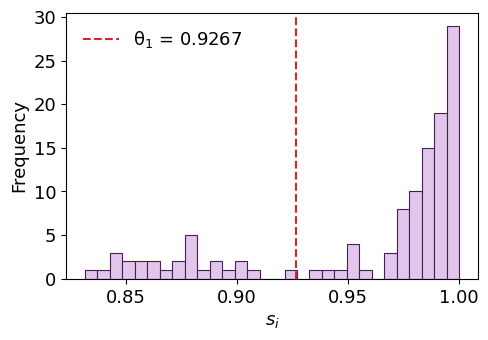

In [9]:

from matplotlib.ticker import MultipleLocator

def plot_threshold_histogram(all_values, threshold, xlabel, save_path):
    plt.figure(figsize=(5,3.5))
    plt.hist(all_values, bins=30, color='#e2c6ea' , edgecolor='#4a1c5c', linewidth=0.8)   #'#c9a3d4'
    plt.axvline(threshold, color='#d62728', linestyle='--', linewidth=1.5, label=f'θ$_1$ = {threshold:.4f}')
    plt.xlabel(xlabel, fontsize=13)
    plt.ylabel('Frequency', fontsize=13)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(fontsize=13, frameon=False)
    plt.gca().xaxis.set_major_locator(MultipleLocator(0.05))
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

plot_threshold_histogram(all_sims_full_B, threshold_otsu_full_B,
    r'$s_i$', 'histograma_theta1_B.png')

In [10]:
 threshold_otsu_full_B

0.9267106771469116

In [11]:
# print(list(all_sims_full_B))

#### Creating an image to show the two stages (the two criteria)


In [12]:

def plot_group_transition_figure(items_sorted, case_ids, value_fn, threshold,
                                   group_k_size, criterion_label, value_label,
                                   save_path, higher_means_different=False,
                                   fusiona_grupos=False, size=(128,128), theta_index=1):
    
    """
    Generate a composite figure: a row of consecutive images, transition values
    between each pair, a threshold line, and grouping brackets (Gk / Gk+1). 

    - case_ids: case numbers in order, spanning both groups. 
    - group_k_size: number of initial case_ids belonging to Gk. 
    - value_fn: function(path_a, path_b) -> numerical signal value. 
    - higher_means_different:
             - True if HIGH values indicate a group change (e.g., caudal margin);
             - False if LOW values indicate a group change (e.g., cosine similarity).
    """
    path_by_case = {n: p for n, p in items_sorted}
    paths = [path_by_case[c] for c in case_ids]
    n = len(paths)
    values = [value_fn(paths[i], paths[i+1]) for i in range(n-1)]

    fig, (ax_img, ax_val) = plt.subplots(2, 1, figsize=(2.2*n, 4.5),
                                           gridspec_kw={'height_ratios': [3, 1]})

    for i, p in enumerate(paths):
        img = Image.open(p).convert('L').resize(size)
        ax_img.imshow(np.array(img), extent=(i+0.00, i+0.96, 0, 1), cmap='gray')
    ax_img.set_xlim(0, n); ax_img.set_ylim(-0.25, 1.15); ax_img.axis('off')
    for i, c in enumerate(case_ids):
        ax_img.text(i+0.5, 1.05, f"Case {c}", ha='center', fontsize=12)

    #ax_img.plot([0, group_k_size], [-0.08]*2, color='tab:blue', lw=3)
    #ax_img.text(group_k_size/2, -0.18, r'Grupo $G_k$', ha='center', color='tab:blue', fontsize=10)
    #ax_img.plot([group_k_size, n], [-0.08]*2, color='tab:green', lw=3)
    #ax_img.text((group_k_size+n)/2, -0.18, r'Grupo $G_{k+1}$', ha='center', color='tab:green', fontsize=10)
    if fusiona_grupos:
        ax_img.plot([0, n], [-0.08]*2, color='teal', lw=3)
        ax_img.text(n/2, -0.18, r'Fused block', ha='center', color='teal', fontsize=12)
        ax_img.plot([group_k_size, group_k_size], [-0.05, -0.11], color='gray', linestyle=':', lw=1)
    else:
        ax_img.plot([0, group_k_size], [-0.08]*2, color='darkorange', lw=3)
        ax_img.text(group_k_size/2, -0.18, r'Block $B_k$', ha='center', color='darkorange', fontsize=12)
        ax_img.plot([group_k_size, n], [-0.08]*2, color='teal', lw=3)
        ax_img.text((group_k_size+n)/2, -0.18, r'Block $B_{k+1}$', ha='center', color='teal', fontsize=12)
    
    #ax_val.axhline(threshold, color='red', linestyle='--', label=f'θ = {threshold:.4f}')
    ax_val.axhline(threshold, color='red', linestyle='--', label=f'θ$_{theta_index}$ = {threshold:.4f}')
    xs = [i+1 for i in range(n-1)]
    transition_idx = group_k_size - 1
    #if higher_means_different:
    #    colors = ['tab:red' if v > threshold else 'tab:gray' for v in values]
    #else:
    #    colors = ['tab:red' if v < threshold else 'tab:gray' for v in values]
    #colors[transition_idx] = 'tab:purple' if fusiona_grupos else 'crimson'

    if higher_means_different:
        colors = ['tab:red' if v > threshold else 'tab:purple' for v in values]
    else:
        colors = ['tab:red' if v < threshold else 'tab:purple' for v in values]
    colors[transition_idx] = 'tab:red' if fusiona_grupos == False else 'tab:purple'
    
    #ax_val.bar(xs, values, width=0.3, color=colors)
    #for x, v in zip(xs, values):
    #    ax_val.text(x, v, f"{v:.3f}", ha='center', va='bottom', fontsize=8)
    ax_val.bar(xs, values, width=0.5, color=colors, alpha=0.35)
    y_max = max(values) if max(values) > 0 else 1
    for x, v in zip(xs, values):
        y_text = v/2 if v > y_max*0.15 else y_max*0.08
        va = 'center' if v > y_max*0.15 else 'bottom'
        ax_val.text(x, y_text, f"{v:.3f}", ha='center', va=va, fontsize=16) # tamaño de los núemros de dentro, negrita:fontweight='bold'
        
    ax_val.set_xlim(0, n); ax_val.set_xticks([])
    
    #ax_val.legend(loc='best', fontsize=15)
    ax_val.legend(loc='upper right', fontsize=11)  # o 'lower left', 'upper left', 'lower right'
    
    ax_val.set_title(criterion_label, fontsize=12)  # Tamaño del nombre del criterio

    ax_val.set_yticks([]); ax_val.set_ylabel(value_label, fontsize=15)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

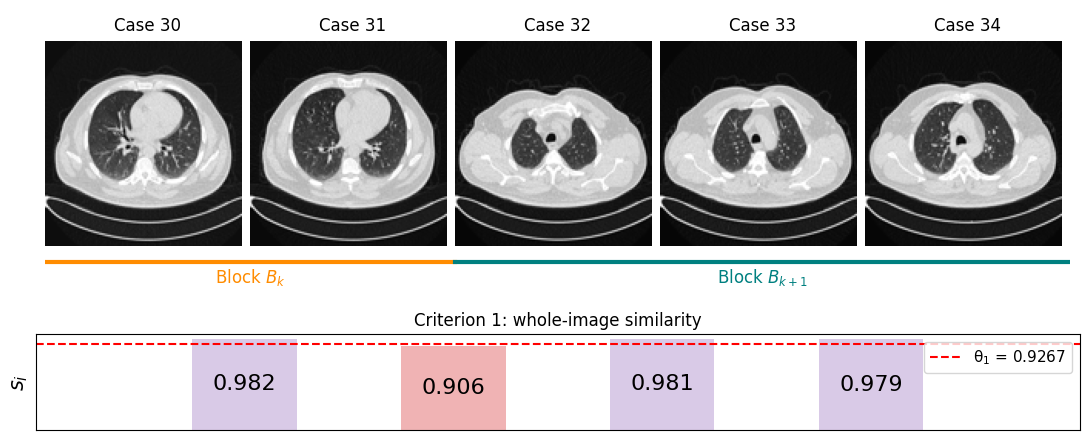

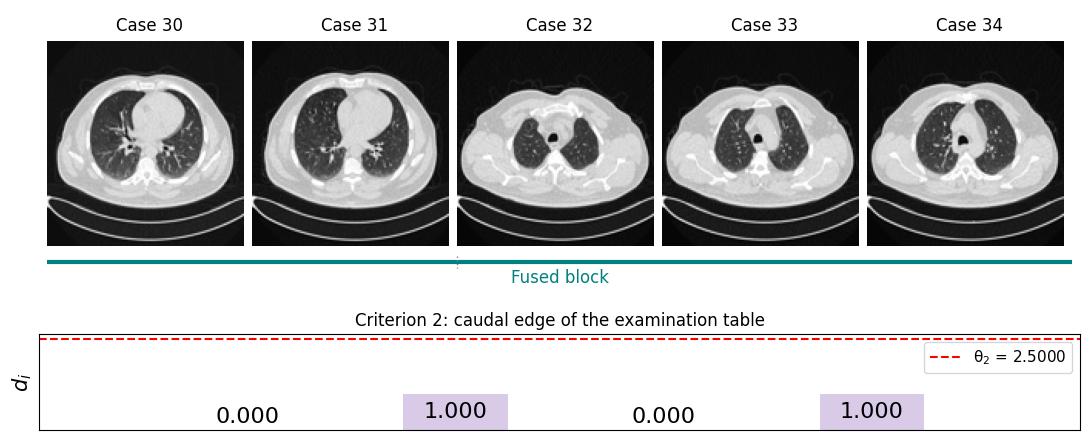

In [13]:
#...............................................................
# First criterion, Benigno class
#...............................................................

plot_group_transition_figure(
    items_B, case_ids=[30, 31, 32, 33, 34],
    value_fn=sim_full_pair, threshold=threshold_otsu_full_B,
    group_k_size=2, higher_means_different=False,
    criterion_label='Criterion 1: whole-image similarity',
    value_label=r'$s_i$',  # (similitud coseno)
    save_path='figura_criterio1.png',
    theta_index=1
)

#...............................................................
# Second criterion, Benigno class.
#...............................................................

def margin_diff_pair(path_a, path_b):
    fa = extract_detailed_couch_features(path_a)
    fb = extract_detailed_couch_features(path_b)
    return abs(fa['couch_bottom_to_border'] - fb['couch_bottom_to_border'])

plot_group_transition_figure(
    items_B, case_ids=[30, 31, 32, 33, 34],
    value_fn=margin_diff_pair, threshold=threshold_iqr,
    group_k_size=2, higher_means_different=True,
    fusiona_grupos=True,
    criterion_label='Criterion 2: caudal edge of the examination table',
    value_label=r'$d_i$',
    save_path='figura_criterio2.png',
    theta_index=2

)
